In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import keras as kf
from keras.utils import image_dataset_from_directory, to_categorical
from keras.layers import (Conv2D, BatchNormalization, Activation,
                           MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score,
                              roc_curve, auc)
from sklearn.utils.class_weight import compute_class_weight

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU is available!")
    print("GPU devices:", gpus)
else:
    print("GPU is NOT available. Using CPU.")

GPU is available!
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:

input_shape=(224,224,1)
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 30
DATASET_PATH = "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"
SEED=42
AUTOTUNE= tf.data.AUTOTUNE   
np.random.seed(SEED)
tf.random.set_seed(SEED)

train_data= image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="grayscale"     
)

val_data =  image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="grayscale"  
)



class_names = train_data.class_names
print("Classes:", class_names)   
NUM_CLASSES = len(class_names)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="augmentation")

normalization_layer = tf.keras.layers.Rescaling(1./255)
train_data = (train_data
              .map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
              .cache()
              .prefetch(AUTOTUNE))

val_data = (val_data
            .map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
            .cache()
            .prefetch(AUTOTUNE))

all_labels = []
for _, labels in train_data:
    all_labels.extend(np.argmax(labels.numpy(), axis=1))
all_labels = np.array(all_labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_labels),
    y=all_labels
)
class_weight = dict(enumerate(class_weights))
print("Class weights:", class_weight)

Found 12446 files belonging to 4 classes.
Using 9957 files for training.
Found 12446 files belonging to 4 classes.
Using 2489 files for validation.
Classes: ['Cyst', 'Normal', 'Stone', 'Tumor']
Class weights: {0: 0.8339195979899497, 1: 0.6125123031496063, 2: 2.23451526032316, 3: 1.3875418060200668}


In [9]:
for x, y in train_data.take(1):
    print(x.shape, y.shape)

(32, 224, 224, 1) (32, 4)


Epoch 1/30
312/312 [==============================] - 63s 190ms/step - loss: 0.9403 - accuracy: 0.6206 - val_loss: 3.1840 - val_accuracy: 0.1057 - lr: 1.0000e-04
Epoch 2/30
312/312 [==============================] - 59s 189ms/step - loss: 0.6248 - accuracy: 0.7805 - val_loss: 3.1282 - val_accuracy: 0.2166 - lr: 1.0000e-04
Epoch 3/30
312/312 [==============================] - 59s 189ms/step - loss: 0.4341 - accuracy: 0.8536 - val_loss: 1.5395 - val_accuracy: 0.3604 - lr: 1.0000e-04
Epoch 4/30
312/312 [==============================] - 59s 189ms/step - loss: 0.3149 - accuracy: 0.8955 - val_loss: 0.4328 - val_accuracy: 0.8284 - lr: 1.0000e-04
Epoch 5/30
312/312 [==============================] - 59s 189ms/step - loss: 0.2300 - accuracy: 0.9270 - val_loss: 0.2335 - val_accuracy: 0.9273 - lr: 1.0000e-04
Epoch 6/30
312/312 [==============================] - 59s 188ms/step - loss: 0.1785 - accuracy: 0.9465 - val_loss: 0.2213 - val_accuracy: 0.9192 - lr: 1.0000e-04
Epoch 7/30
312/312 [========

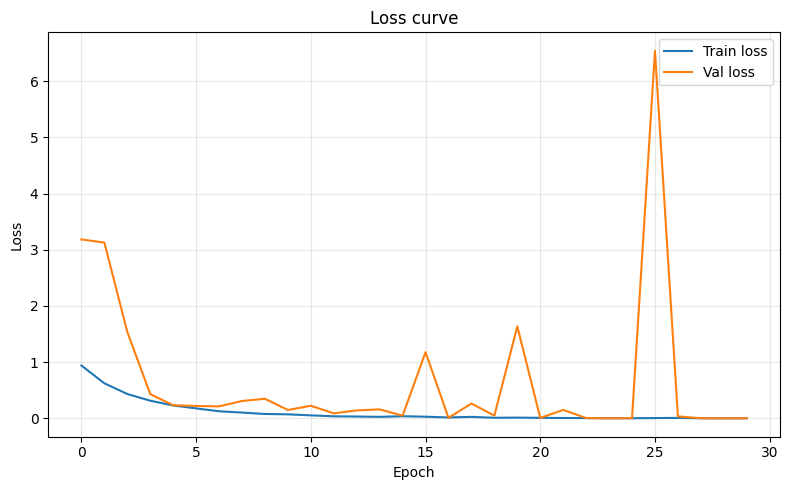

In [12]:
model=kf.Sequential([
    #block 1
    Conv2D(32,(3,3),padding="same",input_shape=input_shape),
    BatchNormalization(),
    Activation("relu"),
    Conv2D(32,(3,3),padding="same"),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D(),

    #block 2
    Conv2D(64,(3,3),padding="same"),
    BatchNormalization(),
    Activation("relu"),
    Conv2D(64,(3,3),padding="same"),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D(),

    #block 3
    Conv2D(128,(3,3),padding="same"),
    BatchNormalization(),
    Activation("relu"),
    Conv2D(128,(3,3),padding="same"),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D(),




    #final
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES,activation="softmax")
])
model.compile(
    optimizer=kf.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight
)

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"],     label="Train loss")
plt.plot(history.history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



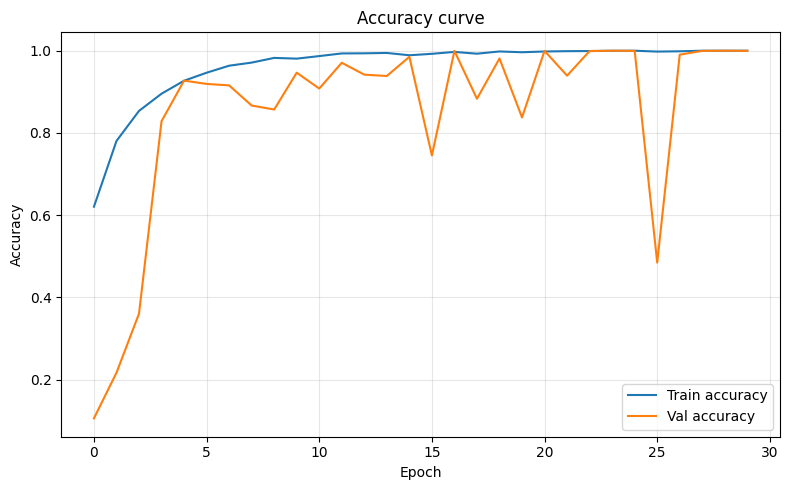

Inference time: 7.37s


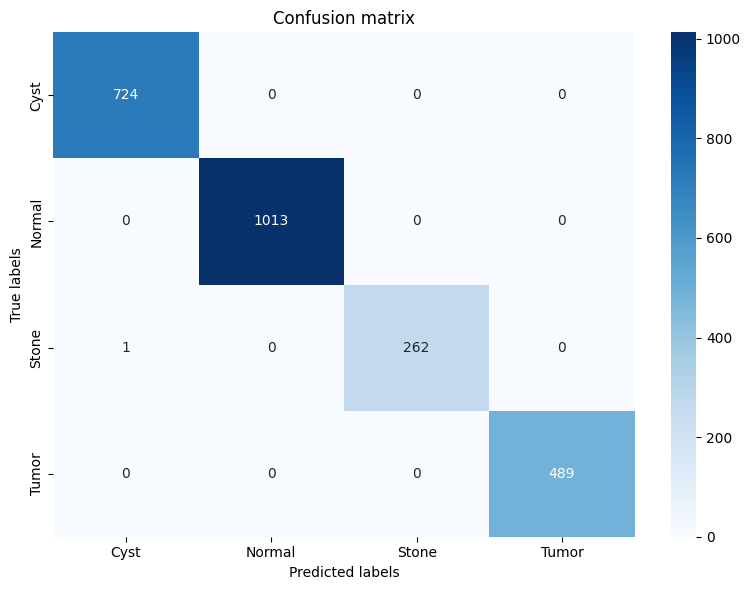


Classification Report:
              precision    recall  f1-score   support

        Cyst       1.00      1.00      1.00       724
      Normal       1.00      1.00      1.00      1013
       Stone       1.00      1.00      1.00       263
       Tumor       1.00      1.00      1.00       489

    accuracy                           1.00      2489
   macro avg       1.00      1.00      1.00      2489
weighted avg       1.00      1.00      1.00      2489

Accuracy for 'Cyst': 1.0000
Accuracy for 'Normal': 1.0000
Accuracy for 'Stone': 0.9962
Accuracy for 'Tumor': 1.0000

Overall Accuracy : 99.96%
Precision        : 99.97%
Recall           : 99.90%
F1-Score         : 99.94%


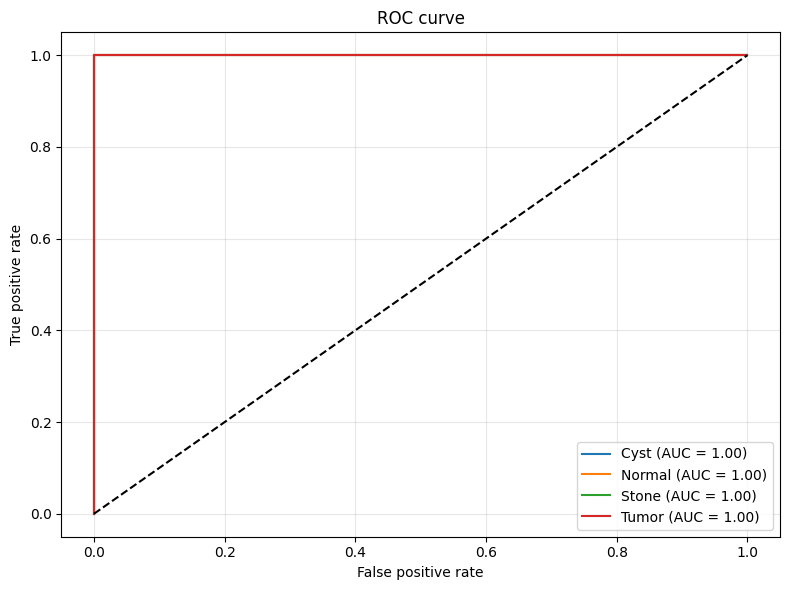

In [13]:
#   Accuracy curve  
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"],     label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#   Collect predictions 
start_test_time = time.time()

y_true, y_pred_prob = [], []
for images, labels in val_data:                         
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_prob.extend(preds)

y_true         = np.array(y_true)
y_pred_prob    = np.array(y_pred_prob)
y_pred_classes = np.argmax(y_pred_prob, axis=1)

testing_time = time.time() - start_test_time
print(f"Inference time: {testing_time:.2f}s")

#   Confusion matrix  
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion matrix")
plt.tight_layout()
plt.show()

# ── Classification report ──────────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# ── Per-class accuracy ─────────────────────────────────────────────────
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, name in enumerate(class_names):
    print(f"Accuracy for '{name}': {class_accuracy[i]:.4f}")

# ── Overall metrics ────────────────────────────────────────────────────
accuracy  = np.sum(y_pred_classes == y_true) / len(y_true)
precision = precision_score(y_true, y_pred_classes, average="macro")
recall    = recall_score(y_true, y_pred_classes, average="macro")
f1        = f1_score(y_true, y_pred_classes, average="macro")

print(f"\nOverall Accuracy : {accuracy*100:.2f}%")
print(f"Precision        : {precision*100:.2f}%")
print(f"Recall           : {recall*100:.2f}%")
print(f"F1-Score         : {f1*100:.2f}%")

# ── ROC curve ──────────────────────────────────────────────────────────
y_true_onehot = to_categorical(y_true, num_classes=NUM_CLASSES)
plt.figure(figsize=(8, 6))
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC curve")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Create a separate test set — 10% of data
test_data = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.1,
    subset="validation",       # use as test
    seed=123,                  # DIFFERENT seed than training!
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="grayscale"
)

# Apply same normalization
test_data = (test_data
             .map(lambda x, y: (normalization_layer(x), y),
                  num_parallel_calls=AUTOTUNE)
             .prefetch(AUTOTUNE))

# Evaluate
loss, acc = model.evaluate(test_data)
print(f"Test Accuracy: {acc*100:.2f}%")

Found 12446 files belonging to 4 classes.
Using 1244 files for validation.
39/39 [==============================] - 3s 55ms/step - loss: 0.0013 - accuracy: 1.0000
Test Accuracy: 100.00%
